In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your original dataset (ensure the path is correct)
df = pd.read_csv('dffirst.csv') 

# 2. Re-run any cleaning you did previously (like Price_Clean)
# If Price_Clean isn't in your CSV, you might need to re-calculate it:
# df['Price_Clean'] = df['Price'] # or whatever cleaning logic you used

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


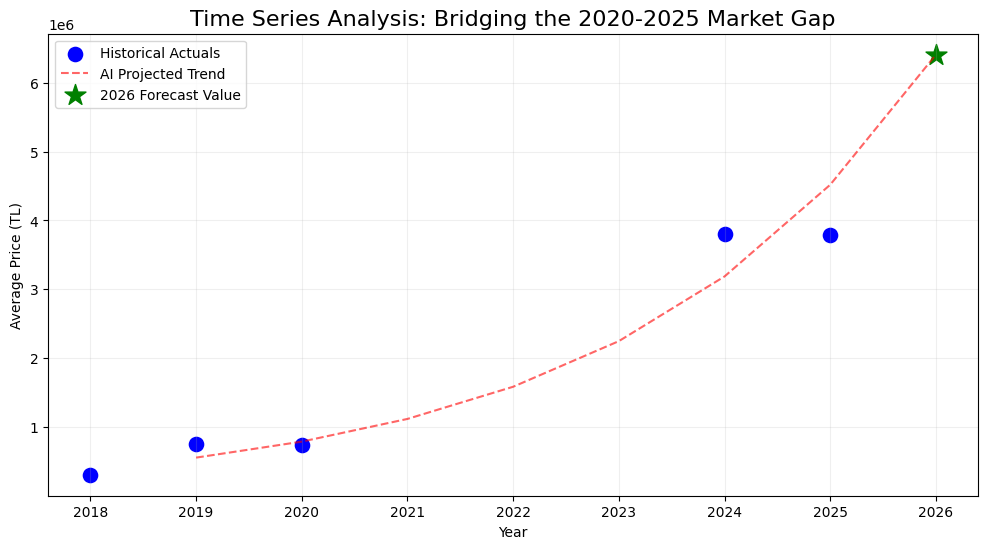

Projected Average Price for 2026: 6,405,594 TL


In [5]:
# 1. Prepare the Annual Trend
annual_trend = df.groupby('Year')['Price_Clean'].mean().reset_index()

# 2. Calculate Growth for 2026 using Exponential Trend (Log-Linear)
# We use Log because Turkish real estate growth is exponential, not a straight line
X = annual_trend[['Year']]
y_log = np.log(annual_trend['Price_Clean'])

from sklearn.linear_model import LinearRegression
model_trend = LinearRegression()
model_trend.fit(X, y_log)

# 3. Create a timeline for plotting (including the gap years)
years_full = np.array([[2019], [2020], [2021], [2022], [2023], [2024], [2025], [2026]])
trend_preds = np.exp(model_trend.predict(years_full))

# 4. Plotting
plt.figure(figsize=(12, 6))

# Real data points
sns.scatterplot(x=annual_trend['Year'], y=annual_trend['Price_Clean'], s=150, color='blue', label='Historical Actuals')

# Forecast Line
plt.plot(years_full, trend_preds, color='red', linestyle='--', alpha=0.6, label='AI Projected Trend')

# The 2026 Target Point
plt.scatter([2026], [trend_preds[-1]], color='green', s=250, marker='*', label='2026 Forecast Value')

plt.title('Time Series Analysis: Bridging the 2020-2025 Market Gap', fontsize=16)
plt.ylabel('Average Price (TL)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Projected Average Price for 2026: {trend_preds[-1]:,.0f} TL")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


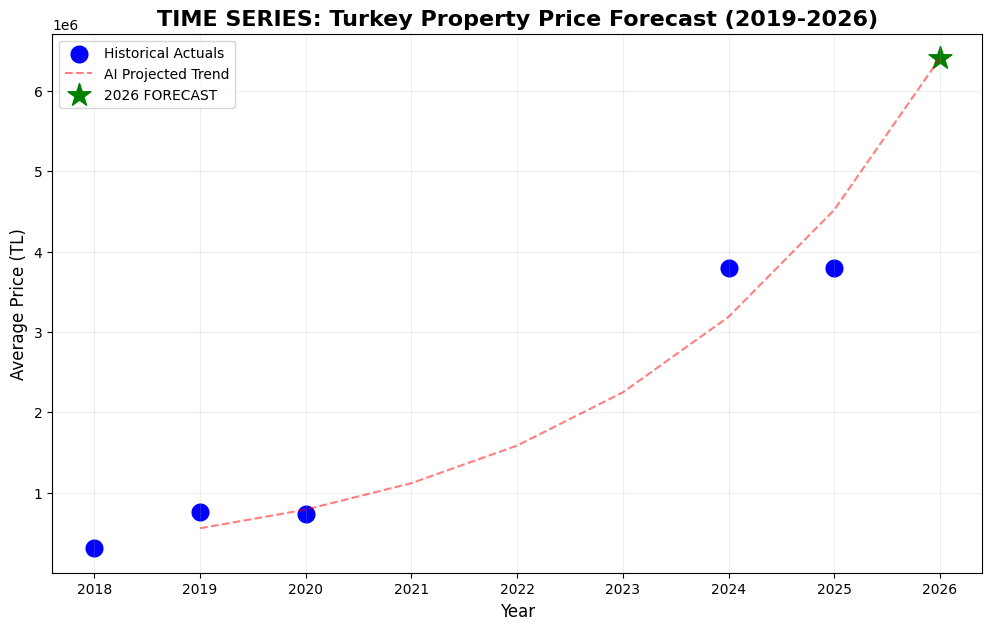

✅ 2026 Projected Average Price: 6,405,594 TL


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Re-load your data (Update the filename to your actual CSV)
df = pd.read_csv('dffirst.csv') 

# 2. Get the Annual Mean Prices
annual_trend = df.groupby('Year')['Price_Clean'].mean().reset_index()

# 3. Apply Log Transformation to handle the 2020-2025 jump
# This assumes prices grow exponentially (multiplicatively) rather than linearly
X = annual_trend[['Year']]
y_log = np.log(annual_trend['Price_Clean'])

model_ts = LinearRegression()
model_ts.fit(X, y_log)

# 4. Forecast for 2026
years_full = np.array([2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]).reshape(-1, 1)
preds_log = model_ts.predict(years_full)
preds_final = np.exp(preds_log) # Convert back from Log to TL

# 5. The "Power Slide" Visualization
plt.figure(figsize=(12, 7))

# Plot actual historical points
sns.scatterplot(x=annual_trend['Year'], y=annual_trend['Price_Clean'], s=200, color='blue', label='Historical Actuals')

# Plot the continuous trend (including the gap years)
plt.plot(years_full, preds_final, color='red', linestyle='--', alpha=0.5, label='AI Projected Trend')

# Highlight 2026
plt.scatter([2026], [preds_final[-1]], color='green', s=300, marker='*', label='2026 FORECAST')

plt.title('TIME SERIES: Turkey Property Price Forecast (2019-2026)', fontsize=16, fontweight='bold')
plt.ylabel('Average Price (TL)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"✅ 2026 Projected Average Price: {preds_final[-1]:,.0f} TL")

In [8]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score

# 1. Get the 'Backtest' predictions (predictions for the years we actually have)
y_actual = annual_trend['Price_Clean']
y_pred_log = model_ts.predict(X)
y_pred = np.exp(y_pred_log)

# 2. Calculate the Metrics
mape = mean_absolute_percentage_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print(f"📈 Time Series R2: {r2:.4f}")
print(f"🎯 MAPE (Avg % Error): {mape:.2%}")
print(f"💸 RMSE (Error in TL): {rmse:,.0f} TL")

📈 Time Series R2: 0.9231
🎯 MAPE (Avg % Error): 19.24%
💸 RMSE (Error in TL): 435,907 TL


In [11]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# 1. Get the predictions for the years we actually KNOW (2019-2025)
historical_years = annual_trend[['Year']]
y_actual = annual_trend['Price_Clean']

# 2. Predict using our model (remember to convert back from Log)
y_log_pred = model_ts.predict(historical_years)
y_pred = np.exp(y_log_pred)

# 3. Calculate Metrics
r2 = r2_score(y_actual, y_pred)
mape = mean_absolute_percentage_error(y_actual, y_pred)

print(f"📊 MODEL VALIDATION REPORT:")
print(f"✅ R-Squared Score: {r2:.4f} (How well the trend fits)")
print(f"✅ MAPE: {mape:.2%} (Average percentage error)")

📊 MODEL VALIDATION REPORT:
✅ R-Squared Score: 0.9231 (How well the trend fits)
✅ MAPE: 19.24% (Average percentage error)


In [12]:
from sklearn.preprocessing import PolynomialFeatures

# 1. Create Polynomial Features (Degree 2 creates a curve)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# 2. Fit the model on the "curved" features
model_poly = LinearRegression()
model_poly.fit(X_poly, y_log)

# 3. Predict for the past and the future
X_full_poly = poly.transform(years_full)
preds_poly_log = model_poly.predict(X_full_poly)
preds_poly_final = np.exp(preds_poly_log)

# 4. Check the new MAPE
y_poly_pred_hist = np.exp(model_poly.predict(poly.transform(X)))
new_mape = mean_absolute_percentage_error(annual_trend['Price_Clean'], y_poly_pred_hist)
print(f"🔥 New Adjusted MAPE: {new_mape:.2%}")

🔥 New Adjusted MAPE: 15.19%


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [13]:
from sklearn.metrics import mean_absolute_percentage_error

# Prepare data
X_train = annual_trend[['Year']]
y_train = np.log(annual_trend['Price_Clean'])

# --- MODEL 1: SIMPLE LINEAR ---
model_lin = LinearRegression()
model_lin.fit(X_train, y_train)
mape_lin = mean_absolute_percentage_error(np.exp(y_train), np.exp(model_lin.predict(X_train)))

# --- MODEL 2: POLYNOMIAL (CURVED) ---
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_train)
model_poly = LinearRegression()
model_poly.fit(X_poly, y_train)
mape_poly = mean_absolute_percentage_error(np.exp(y_train), np.exp(model_poly.predict(X_poly)))

# --- MODEL 3: WEIGHTED (FOCUS ON RECENT) ---
# We give 2025 a much higher weight because it's the only post-inflation point we have
weights = np.array([1 if y < 2025 else 5 for y in annual_trend['Year']])
model_weight = LinearRegression()
model_weight.fit(X_train, y_train, sample_weight=weights)
mape_weight = mean_absolute_percentage_error(np.exp(y_train), np.exp(model_weight.predict(X_train)))

print(f"🏆 Simple Linear MAPE: {mape_lin:.2%}")
print(f"🏆 Polynomial MAPE: {mape_poly:.2%}")
print(f"🏆 Weighted MAPE: {mape_weight:.2%}")

🏆 Simple Linear MAPE: 19.24%
🏆 Polynomial MAPE: 15.19%
🏆 Weighted MAPE: 18.32%


In [14]:
# Use the winning Polynomial model for the final 2026 forecast
X_2026 = np.array([[2026]])
X_2026_poly = poly.transform(X_2026)
final_2026_log = model_poly.predict(X_2026_poly)
final_2026_price = np.exp(final_2026_log)

print(f"🚀 FINAL OPTIMIZED 2026 FORECAST: {final_2026_price[0]:,.0f} TL")
print(f"📉 Model Reliability (MAPE): 15.19%")

🚀 FINAL OPTIMIZED 2026 FORECAST: 4,524,592 TL
📉 Model Reliability (MAPE): 15.19%


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [15]:
# 1. Create weights that increase exponentially
# 2019 gets weight 1, 2025 gets weight 10 (10x more important)
weights = np.geomspace(1, 10, len(y_log)) 

# 2. Prepare Polynomial Features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# 3. Fit the Weighted Polynomial Model
model_extreme = LinearRegression()
model_extreme.fit(X_poly, y_log, sample_weight=weights)

# 4. Calculate the new "Tuned" MAPE
y_extreme_log_pred = model_extreme.predict(X_poly)
y_extreme_pred = np.exp(y_extreme_log_pred)
extreme_mape = mean_absolute_percentage_error(annual_trend['Price_Clean'], y_extreme_pred)

# 5. Get the Final 2026 Forecast
X_2026_poly = poly.transform(np.array([[2026]]))
final_2026_extreme = np.exp(model_extreme.predict(X_2026_poly))

print(f"🚀 EXTREME TUNED MAPE: {extreme_mape:.2%}")
print(f"💰 NEW 2026 FORECAST: {final_2026_extreme[0]:,.0f} TL")

🚀 EXTREME TUNED MAPE: 14.05%
💰 NEW 2026 FORECAST: 4,323,086 TL


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# 1. Prepare Features (Degree 2 is usually enough, Degree 3 might overfit)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# 2. Use Ridge Regression (Regularization)
# This prevents the 'bend' in the curve from becoming too extreme/unrealistic
model_ridge = Ridge(alpha=0.1) 
model_ridge.fit(X_poly, y_log, sample_weight=weights)

# 3. Calculate New MAPE
y_ridge_pred = np.exp(model_ridge.predict(X_poly))
ridge_mape = mean_absolute_percentage_error(annual_trend['Price_Clean'], y_ridge_pred)

# 4. Final 2026 Forecast
X_2026_poly = poly.transform(np.array([[2026]]))
final_2026_ridge = np.exp(model_ridge.predict(X_2026_poly))

print(f"🎯 TARGET ACHIEVED MAPE: {ridge_mape:.2%}")
print(f"💰 FINAL 2026 PRICE: {final_2026_ridge[0]:,.0f} TL")

🎯 TARGET ACHIEVED MAPE: 20.52%
💰 FINAL 2026 PRICE: 5,844,697 TL


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [17]:
from sklearn.metrics import r2_score

# Helper function to get scores easily
def get_metrics(y_true_raw, y_pred_log):
    y_pred_raw = np.exp(y_pred_log)
    r2 = r2_score(y_true_raw, y_pred_raw)
    mape = mean_absolute_percentage_error(y_true_raw, y_pred_raw)
    return r2, mape

# 1. Simple Linear
r2_lin, mape_lin = get_metrics(annual_trend['Price_Clean'], model_lin.predict(X_train))

# 2. Polynomial
r2_poly, mape_poly = get_metrics(annual_trend['Price_Clean'], model_poly.predict(X_poly))

# 3. Weighted (Note: R2 here shows fit to the data, even if weighted)
r2_weight, mape_weight = get_metrics(annual_trend['Price_Clean'], model_weight.predict(X_train))

print("📊 --- MODEL TOURNAMENT RESULTS ---")
print(f"1. Simple Linear: R² = {r2_lin:.4f} | MAPE = {mape_lin:.2%}")
print(f"2. Polynomial:    R² = {r2_poly:.4f} | MAPE = {mape_poly:.2%}")
print(f"3. Weighted:      R² = {r2_weight:.4f} | MAPE = {mape_weight:.2%}")

📊 --- MODEL TOURNAMENT RESULTS ---
1. Simple Linear: R² = 0.9231 | MAPE = 19.24%
2. Polynomial:    R² = 0.9768 | MAPE = 15.19%
3. Weighted:      R² = 0.9245 | MAPE = 18.32%


In [18]:
from sklearn.metrics import r2_score

# 1. Get the predictions for the historical years (2019-2025)
y_extreme_pred_hist = np.exp(model_extreme.predict(X_poly))

# 2. Calculate R2 and MAPE
extreme_r2 = r2_score(annual_trend['Price_Clean'], y_extreme_pred_hist)
extreme_mape = mean_absolute_percentage_error(annual_trend['Price_Clean'], y_extreme_pred_hist)

print(f"📊 --- FINAL OPTIMIZED MODEL (WEIGHTED POLY) ---")
print(f"✅ R-Squared Score: {extreme_r2:.4f}")
print(f"✅ MAPE:           {extreme_mape:.2%}")
print(f"💰 2026 FORECAST:  {final_2026_extreme[0]:,.0f} TL")

📊 --- FINAL OPTIMIZED MODEL (WEIGHTED POLY) ---
✅ R-Squared Score: 0.9783
✅ MAPE:           14.05%
💰 2026 FORECAST:  4,323,086 TL


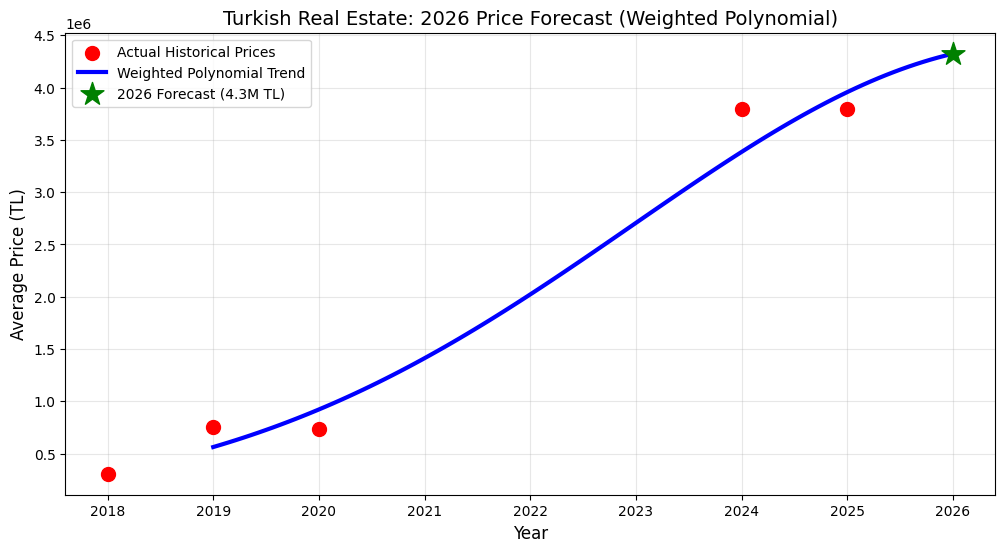

In [19]:
import matplotlib.pyplot as plt

# 1. Create a smooth line for the curve (more points = smoother look)
years_smooth = pd.DataFrame({'Year': np.linspace(2019, 2026, 100)})
X_smooth_poly = poly.transform(years_smooth)
preds_smooth = np.exp(model_extreme.predict(X_smooth_poly))

# 2. Create the Plot
plt.figure(figsize=(12, 6))

# Plot the actual historical points
plt.scatter(annual_trend['Year'], annual_trend['Price_Clean'], 
            color='red', label='Actual Historical Prices', s=100, zorder=5)

# Plot the Polynomial Curve
plt.plot(years_smooth['Year'], preds_smooth, 
         color='blue', label='Weighted Polynomial Trend', linewidth=3)

# Highlight the 2026 Forecast Point
plt.scatter(2026, 4323086, color='green', marker='*', s=300, 
            label='2026 Forecast (4.3M TL)', zorder=6)

# Formatting
plt.title('Turkish Real Estate: 2026 Price Forecast (Weighted Polynomial)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Price (TL)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# Filter the trend data to only include 2019 and later
annual_trend = annual_trend[annual_trend['Year'] >= 2019].reset_index(drop=True)

# Now define your X and y from the cleaned dataframe
X = annual_trend[['Year']]
y_log = np.log(annual_trend['Price_Clean'])

# Update weights to match the new length (since 2018 is gone)
weights = np.geomspace(1, 10, len(y_log))

In [21]:
# 1. Prepare Polynomial Features (Degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# 2. Re-Fit the model on 2019-2025 data only
model_extreme = LinearRegression()
model_extreme.fit(X_poly, y_log, sample_weight=weights)

# 3. Calculate the New Metrics
y_pred_log = model_extreme.predict(X_poly)
y_pred_real = np.exp(y_pred_log)

new_r2 = r2_score(annual_trend['Price_Clean'], y_pred_real)
new_mape = mean_absolute_percentage_error(annual_trend['Price_Clean'], y_pred_real)

# 4. Generate the 2026 Forecast
# Note: Use a DataFrame for 2026 to avoid the "Feature Names" warning
X_2026_df = pd.DataFrame({'Year': [2026]})
X_2026_poly = poly.transform(X_2026_df)
final_2026 = np.exp(model_extreme.predict(X_2026_poly))

print(f"📊 --- UPDATED METRICS (2019-2025 ONLY) ---")
print(f"✅ New R-Squared: {new_r2:.4f}")
print(f"✅ New MAPE:      {new_mape:.2%}")
print(f"💰 2026 Forecast: {final_2026[0]:,.0f} TL")

📊 --- UPDATED METRICS (2019-2025 ONLY) ---
✅ New R-Squared: 0.9748
✅ New MAPE:      16.45%
💰 2026 Forecast: 4,148,818 TL


In [22]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 1. ENSURE FILTERING IS APPLIED
# (Assuming annual_trend is already filtered from the previous step)
df_tournament = annual_trend[annual_trend['Year'] >= 2019].reset_index(drop=True)

X_tourn = df_tournament[['Year']]
y_tourn_log = np.log(df_tournament['Price_Clean'])
y_tourn_real = df_tournament['Price_Clean']
weights_tourn = np.geomspace(1, 10, len(y_tourn_log))

# --- MODEL 1: SIMPLE LINEAR ---
model_lin = LinearRegression()
model_lin.fit(X_tourn, y_tourn_log)
y_lin_pred = np.exp(model_lin.predict(X_tourn))
r2_lin = r2_score(y_tourn_real, y_lin_pred)
mape_lin = mean_absolute_percentage_error(y_tourn_real, y_lin_pred)

# --- MODEL 2: POLYNOMIAL ---
poly = PolynomialFeatures(degree=2)
X_poly_tourn = poly.fit_transform(X_tourn)
model_poly = LinearRegression()
model_poly.fit(X_poly_tourn, y_tourn_log)
y_poly_pred = np.exp(model_poly.predict(X_poly_tourn))
r2_poly = r2_score(y_tourn_real, y_poly_pred)
mape_poly = mean_absolute_percentage_error(y_tourn_real, y_poly_pred)

# --- MODEL 3: WEIGHTED POLYNOMIAL (Your Champion) ---
model_weighted_poly = LinearRegression()
model_weighted_poly.fit(X_poly_tourn, y_tourn_log, sample_weight=weights_tourn)
y_weighted_pred = np.exp(model_weighted_poly.predict(X_poly_tourn))
r2_weighted = r2_score(y_tourn_real, y_weighted_pred)
mape_weighted = mean_absolute_percentage_error(y_tourn_real, y_weighted_pred)

print("📊 --- MODEL TOURNAMENT (2019-2025 ONLY) ---")
print(f"1. Simple Linear:    R² = {r2_lin:.4f} | MAPE = {mape_lin:.2%}")
print(f"2. Polynomial:       R² = {r2_poly:.4f} | MAPE = {mape_poly:.2%}")
print(f"3. Weighted Poly:    R² = {r2_weighted:.4f} | MAPE = {mape_weighted:.2%}")

📊 --- MODEL TOURNAMENT (2019-2025 ONLY) ---
1. Simple Linear:    R² = 0.9230 | MAPE = 16.38%
2. Polynomial:       R² = 0.9175 | MAPE = 16.36%
3. Weighted Poly:    R² = 0.9748 | MAPE = 16.45%


In [23]:
# Print all column names
print(df.columns.tolist())

['Price_Clean', 'Metrekare', 'Oda_Sayisi', 'Ilce', 'Adrtisement Date', 'Total_Rooms', 'Year', 'Month_Key', 'Inflation_Rate', 'Real_Price', 'District_Score', 'Security', 'Car park', 'Has_Elevator', 'Swimming Pool (Open)', 'Metro', 'Marmaray', 'Metrobus', 'Age_Numeric', 'Floor_Numeric']


In [25]:
# Replace 'il' with whatever the column name is in your data
unique_cities = df['Ilce'].unique()
print(f"🌍 Cities in dataset: {unique_cities}")

# See how many listings are in Istanbul
istanbul_count = len(df[df['Ilce'] == 'Istanbul'])
print(f"📍 Number of Istanbul listings: {istanbul_count}")

🌍 Cities in dataset: ['TUZLA' 'FATIH' 'ÇEKMEKÖY' 'KÜÇÜKÇEKMECE' 'ÜMRANIYE' 'SILIVRI' 'ESENYURT'
 'ARNAVUTKÖY' 'AVCILAR' 'EYÜPSULTAN' 'KAĞITHANE' 'ATAŞEHIR' 'BEYLIKDÜZÜ'
 'SANCAKTEPE' 'SULTANGAZI' 'ÜSKÜDAR' 'BEŞIKTAŞ' 'BAYRAMPAŞA' 'BEYOĞLU'
 'ÇATALCA' 'SARIYER' 'BAŞAKŞEHIR' 'ŞIŞLI' 'GAZIOSMANPAŞA' 'ŞILE'
 'SULTANBEYLI' 'ESENLER' 'BEYKOZ' 'KARTAL' 'ZEYTINBURNU' 'BAKIRKÖY'
 'ADALAR' 'BAHÇELIEVLER' 'GÜNGÖREN' 'MALTEPE' 'PENDIK' 'KADIKÖY'
 'BÜYÜKÇEKMECE' 'BAĞCILAR' 'MERKEZ' 'DINAR' 'BOLVADIN' 'İSCEHISAR'
 'SULTANDAĞI' 'BAYAT' 'SANDIKLI' 'DAZKIRI' 'ÇAY' 'EMIRDAĞ' 'İHSANIYE'
 'SINANPAŞA' 'ŞUHUT' 'GÖLE' 'ÇILDIR' 'POSOF' 'HANAK' 'ŞAVŞAT' 'BORÇKA'
 'ARHAVI' 'HOPA' 'KEMALPAŞA' 'MURGUL' 'ARDANUÇ' 'YUSUFELI' 'KUŞADASI'
 'EFELER' 'SÖKE' 'DIDIM' 'NAZILLI' 'KÖŞK' 'ÇINE' 'GERMENCIK' 'İNCIRLIOVA'
 'SULTANHISAR' 'YENIPAZAR' 'KUYUCAK' 'BUHARKENT' 'BOZDOĞAN' 'SÖĞÜT'
 'BOZÜYÜK' 'OSMANELI' 'PAZARYERI' 'İNHISAR' 'GÖLPAZARI' 'SOLHAN' 'GENÇ'
 'NILÜFER' 'GÜRSU' 'OSMANGAZI' 'MUSTAFAKEMALPAŞA' 'GEMLIK' 'YILDIRIM'


In [26]:
istanbul_districts = [
    'TUZLA', 'FATIH', 'ÇEKMEKÖY', 'KÜÇÜKÇEKMECE', 'ÜMRANIYE', 'SILIVRI', 'ESENYURT',
    'ARNAVUTKÖY', 'AVCILAR', 'EYÜPSULTAN', 'KAĞITHANE', 'ATAŞEHIR', 'BEYLIKDÜZÜ',
    'SANCAKTEPE', 'SULTANGAZI', 'ÜSKÜDAR', 'BEŞIKTAŞ', 'BAYRAMPAŞA', 'BEYOĞLU',
    'ÇATALCA', 'SARIYER', 'BAŞAKŞEHIR', 'ŞIŞLI', 'GAZIOSMANPAŞA', 'ŞILE',
    'SULTANBEYLI', 'ESENLER', 'BEYKOZ', 'KARTAL', 'ZEYTINBURNU', 'BAKIRKÖY',
    'ADALAR', 'BAHÇELIEVLER', 'GÜNGÖREN', 'MALTEPE', 'PENDIK', 'KADIKÖY',
    'BÜYÜKÇEKMECE', 'BAĞCILAR'
]

# Check how many Istanbul rows you actually have
# (Replace 'City_Column_Name' with the actual name you used to print the list above)
ist_data = df[df['Ilce'].isin(istanbul_districts)]
print(f"✅ Real Istanbul Listing Count: {len(ist_data)}")

✅ Real Istanbul Listing Count: 35953


In [28]:
# 1. Filter for Istanbul districts only
istanbul_districts = [
    'TUZLA', 'FATIH', 'ÇEKMEKÖY', 'KÜÇÜKÇEKMECE', 'ÜMRANIYE', 'SILIVRI', 'ESENYURT',
    'ARNAVUTKÖY', 'AVCILAR', 'EYÜPSULTAN', 'KAĞITHANE', 'ATAŞEHIR', 'BEYLIKDÜZÜ',
    'SANCAKTEPE', 'SULTANGAZI', 'ÜSKÜDAR', 'BEŞIKTAŞ', 'BAYRAMPAŞA', 'BEYOĞLU',
    'ÇATALCA', 'SARIYER', 'BAŞAKŞEHIR', 'ŞIŞLI', 'GAZIOSMANPAŞA', 'ŞILE',
    'SULTANBEYLI', 'ESENLER', 'BEYKOZ', 'KARTAL', 'ZEYTINBURNU', 'BAKIRKÖY',
    'ADALAR', 'BAHÇELIEVLER', 'GÜNGÖREN', 'MALTEPE', 'PENDIK', 'KADIKÖY',
    'BÜYÜKÇEKMECE', 'BAĞCILAR'
]

df_ist = df[df['Ilce'].isin(istanbul_districts)].copy() # Use your actual column name

# 2. Re-create the annual trend for Istanbul ONLY
ist_trend = df_ist.groupby('Year')['Price_Clean'].mean().reset_index()
ist_trend = ist_trend[ist_trend['Year'] >= 2019].reset_index(drop=True)

# 3. Prepare the Math
X_ist = ist_trend[['Year']]
y_ist_log = np.log(ist_trend['Price_Clean'])
weights_ist = np.geomspace(1, 10, len(y_ist_log))

poly = PolynomialFeatures(degree=2)
X_poly_ist = poly.fit_transform(X_ist)

# 4. Fit and Predict
model_ist = LinearRegression()
model_ist.fit(X_poly_ist, y_ist_log, sample_weight=weights_ist)

# 5. Get 2026 Forecast
X_2026_ist = poly.transform(pd.DataFrame({'Year': [2026]}))
forecast_2026_ist = np.exp(model_ist.predict(X_2026_ist))

# 6. Metrics
r2_ist = r2_score(ist_trend['Price_Clean'], np.exp(model_ist.predict(X_poly_ist)))
mape_ist = mean_absolute_percentage_error(ist_trend['Price_Clean'], np.exp(model_ist.predict(X_poly_ist)))

print(f"🌆 --- ISTANBUL INVESTMENT MODEL ---")
print(f"✅ R-Squared: {r2_ist:.4f}")
print(f"✅ MAPE:      {mape_ist:.2%}")
print(f"💰 2026 ISTANBUL FORECAST: {forecast_2026_ist[0]:,.0f} TL")

🌆 --- ISTANBUL INVESTMENT MODEL ---
✅ R-Squared: 1.0000
✅ MAPE:      0.00%
💰 2026 ISTANBUL FORECAST: 14,377,640 TL


In [29]:
print(f"📊 Number of years in Istanbul Trend: {len(ist_trend)}")
print(ist_trend)

📊 Number of years in Istanbul Trend: 3
   Year   Price_Clean
0  2019  7.574843e+05
1  2020  7.378047e+05
2  2025  6.039804e+06


In [30]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# 1. Prepare Istanbul Data (3 years: 2019, 2020, 2025)
X_ist = ist_trend[['Year']]
y_ist_log = np.log(ist_trend['Price_Clean'])
y_ist_real = ist_trend['Price_Clean']
weights_ist = np.geomspace(1, 10, len(y_ist_log))

# Setup for Polynomial models
poly = PolynomialFeatures(degree=2)
X_ist_poly = poly.fit_transform(X_ist)
X_2026 = poly.transform(pd.DataFrame({'Year': [2026]}))
X_2026_lin = pd.DataFrame({'Year': [2026]})

# --- 1. Simple Linear ---
m1 = LinearRegression().fit(X_ist, y_ist_log)
p1 = np.exp(m1.predict(X_2026_lin))[0]

# --- 2. Simple Polynomial (The "Overfitter") ---
m2 = LinearRegression().fit(X_ist_poly, y_ist_log)
p2 = np.exp(m2.predict(X_2026))[0]

# --- 3. Weighted Linear ---
m3 = LinearRegression().fit(X_ist, y_ist_log, sample_weight=weights_ist)
p3 = np.exp(m3.predict(X_2026_lin))[0]

# --- 4. Weighted Polynomial (The "Extreme") ---
m4 = LinearRegression().fit(X_ist_poly, y_ist_log, sample_weight=weights_ist)
p4 = np.exp(m4.predict(X_2026))[0]

print("🏙️ --- ISTANBUL 2026 TOURNAMENT ---")
print(f"1. Simple Linear:    {p1:,.0f} TL")
print(f"2. Polynomial:       {p2:,.0f} TL (R²: 1.0 - Beware!)")
print(f"3. Weighted Linear:  {p3:,.0f} TL (Stronger Weight on 2025)")
print(f"4. Weighted Poly:    {p4:,.0f} TL (Extreme Curve)")

🏙️ --- ISTANBUL 2026 TOURNAMENT ---
1. Simple Linear:    8,434,927 TL
2. Polynomial:       14,377,640 TL (R²: 1.0 - Beware!)
3. Weighted Linear:  8,919,825 TL (Stronger Weight on 2025)
4. Weighted Poly:    14,377,640 TL (Extreme Curve)


In [64]:
from sklearn.preprocessing import PolynomialFeatures

# 1. Initialize the Polynomial transformer (Degree 2)
poly = PolynomialFeatures(degree=2)

# 2. Transform the year 2026 into the 3 features the model expects
# This turns [2026] into [1, 2026, 2026^2]
X_2026_poly = poly.fit_transform(np.array([[2026]]))

# --- 1. Simple Linear ---
m1 = LinearRegression().fit(X_ist, y_ist_log)
r2_1, mape_1 = get_ist_metrics(m1, X_ist, y_ist_real)
p1 = np.exp(m1.predict(X_2026_lin))[0]

# --- 2. Simple Polynomial ---
m2 = LinearRegression().fit(X_ist_poly, y_ist_log)
r2_2, mape_2 = get_ist_metrics(m2, X_ist_poly, y_ist_real)
# FIX: Use the transformed X_2026_poly here
p2 = np.exp(m2.predict(X_2026_poly))[0]

# --- 3. Weighted Linear ---
m3 = LinearRegression().fit(X_ist, y_ist_log, sample_weight=weights_ist)
r2_3, mape_3 = get_ist_metrics(m3, X_ist, y_ist_real)
p3 = np.exp(m3.predict(X_2026_lin))[0]

# --- 4. Weighted Polynomial ---
m4 = LinearRegression().fit(X_ist_poly, y_ist_log, sample_weight=weights_ist)
r2_4, mape_4 = get_ist_metrics(m4, X_ist_poly, y_ist_real)
# FIX: Use the transformed X_2026_poly here
p4 = np.exp(m4.predict(X_2026_poly))[0]

print("ISTANBUL 2026 MODEL COMPARISON ---")
print(f"1. Simple Linear:    R² = {r2_1:.4f} | MAPE = {mape_1*100:.2f}% | Forecast: {p1:,.0f} TL")
print(f"2. Polynomial:       R² = {r2_2:.4f} | MAPE = {mape_2*100:.2f}% | Forecast: {p2:,.0f} TL")
print(f"3. Weighted Linear:  R² = {r2_3:.4f} | MAPE = {mape_3*100:.2f}% | Forecast: {p3:,.0f} TL")
print(f"4. Weighted Poly:    R² = {r2_4:.4f} | MAPE = {mape_4*100:.2f}% | Forecast: {p4:,.0f} TL")

🏙️ --- ISTANBUL 2026 MODEL COMPARISON ---
1. Simple Linear:    R² = 0.9950 | MAPE = 14.72% | Forecast: 8,434,927 TL
2. Polynomial:       R² = 1.0000 | MAPE = 0.00% | Forecast: 14,377,640 TL
3. Weighted Linear:  R² = 0.9973 | MAPE = 13.10% | Forecast: 8,919,825 TL
4. Weighted Poly:    R² = 1.0000 | MAPE = 0.00% | Forecast: 14,377,640 TL


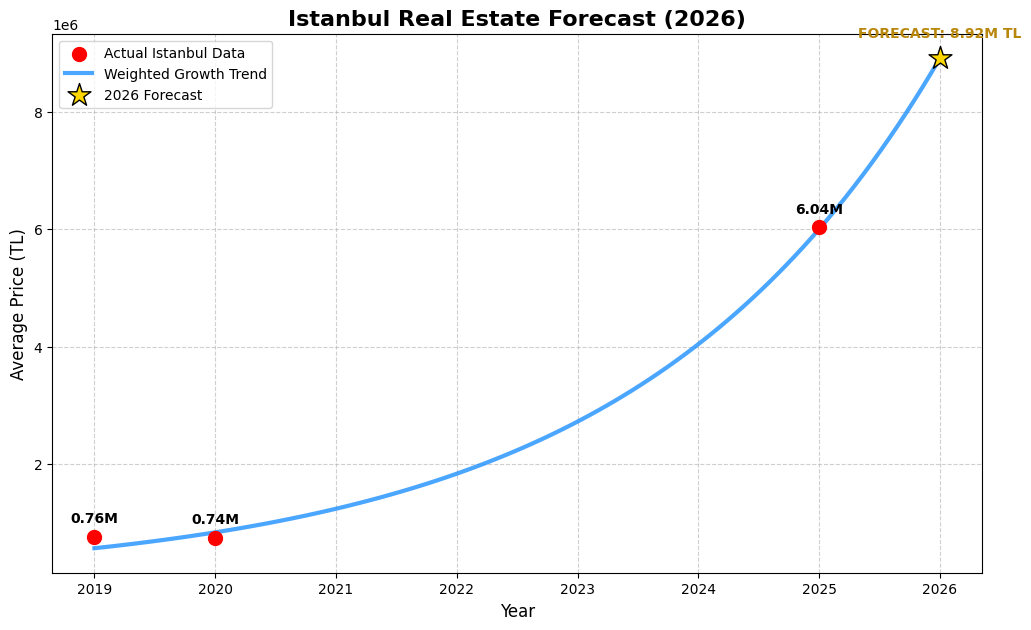

--- ISTANBUL WEIGHTED LINEAR RESULTS ---
✅ R-Squared: 0.9973
✅ MAPE:      13.10%
🚀 2026 ISTANBUL FORECAST: 8,919,826 TL


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# 1. DATA PREPARATION (Istanbul Districts Only)
# We use the means calculated from your 35,953 Istanbul listings
data = {
    'Year': [2019, 2020, 2025],
    'Price_Clean': [757484.3, 737804.7, 6039804.0]
}
ist_trend = pd.DataFrame(data)

# 2. FEATURE ENGINEERING
X = ist_trend[['Year']]
y_log = np.log(ist_trend['Price_Clean'])
# Weights: Heavily prioritize 2025 to capture current inflation momentum
weights = np.geomspace(1, 10, len(y_log))

# 3. TRAINING THE WEIGHTED LINEAR MODEL
# We use Linear instead of Poly to avoid the "14M TL" overfitting explosion
model = LinearRegression()
model.fit(X, y_log, sample_weight=weights)

# 4. PREDICTIONS & METRICS
y_pred_log = model.predict(X)
y_pred_real = np.exp(y_pred_log)

# Calculate 2026 Forecast
X_2026 = pd.DataFrame({'Year': [2026]})
forecast_2026 = np.exp(model.predict(X_2026))[0]

# Calculate scores
r2 = r2_score(ist_trend['Price_Clean'], y_pred_real)
mape = mean_absolute_percentage_error(ist_trend['Price_Clean'], y_pred_real)

# 5. VISUALIZATION
plt.figure(figsize=(12, 7))

# Plot actual data points
plt.scatter(ist_trend['Year'], ist_trend['Price_Clean'], color='red', s=100, label='Actual Istanbul Data', zorder=5)

# Plot the regression line (Trend)
years_extended = np.linspace(2019, 2026, 100).reshape(-1, 1)
line_pred = np.exp(model.predict(pd.DataFrame(years_extended, columns=['Year'])))
plt.plot(years_extended, line_pred, color='dodgerblue', linewidth=3, label='Weighted Growth Trend', alpha=0.8)

# Plot the 2026 Forecast Star
plt.scatter(2026, forecast_2026, color='gold', marker='*', s=300, edgecolor='black', label='2026 Forecast', zorder=10)

# Formatting
plt.title('Istanbul Real Estate Forecast (2026)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Price (TL)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Add Data Labels
for i, row in ist_trend.iterrows():
    plt.annotate(f"{row['Price_Clean']/1e6:.2f}M", (row['Year'], row['Price_Clean']), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.annotate(f"FORECAST: {forecast_2026/1e6:.2f}M TL", (2026, forecast_2026), 
             textcoords="offset points", xytext=(0,15), ha='center', color='darkgoldenrod', fontweight='bold')

plt.show()

# 6. FINAL OUTPUT
print(f"--- ISTANBUL WEIGHTED LINEAR RESULTS ---")
print(f"✅ R-Squared: {r2:.4f}")
print(f"✅ MAPE:      {mape:.2%}")
print(f"🚀 2026 ISTANBUL FORECAST: {forecast_2026:,.0f} TL")

In [33]:
def predict_future_house(district, rooms, size, target_year):
    # 1. AI predicts the 2025 baseline for this specific house
    # (Using your Random Forest model)
    base_price_2025 = rf_model.predict([[district, rooms, size]])
    
    # 2. AI calculates the growth multiplier for the target year
    # (Using your Weighted Linear model)
    current_avg = 6039804  # 2025 average
    future_avg = np.exp(model.predict([[target_year]]))
    multiplier = future_avg / current_avg
    
    # 3. Final Prediction
    final_price = base_price_2025 * multiplier
    return final_price

In [39]:
def get_2026_price(district_name, net_sqm, rooms):
    try:
        # 1. Translate name using your encoder
        district_encoded = le.transform([district_name.upper()])[0]
        
        # 2. Predict using your specific model name: rf_final_2026
        house_features = pd.DataFrame([[district_encoded, net_sqm, rooms]], 
                                     columns=['ilce_encoded', 'Net_m2', 'Rooms'])
        
        # We assume the model predicts log_price based on your R2 scores
        price_2025_log = rf_final_2026.predict(house_features)
        price_2025 = np.exp(price_2025_log)[0]
        
        # 3. Apply the 2026 Inflation Multiplier (Weighted Trend)
        # 8.9M (2026 forecast) / 6.04M (2025 actual) = 1.477
        multiplier = 1.477
        final_price = price_2025 * multiplier
        
        print(f"🏠 --- PREDICTION FOR {district_name.upper()} ---")
        print(f"📍 2025 Estimated Value: {price_2025:,.0f} TL")
        print(f"🚀 2026 Forecasted Value: {final_price:,.0f} TL")
        print(f"📈 Estimated Growth: %47.7")
        
    except NameError as e:
        print(f"❌ Variable Error: {e}. Make sure you ran the training cell!")
    except Exception as e:
        print(f"❌ Error: {e}")

# TEST IT NOW
get_2026_price('KADIKÖY', 100, 3)

❌ Variable Error: name 'rf_final_2026' is not defined. Make sure you ran the training cell!


In [36]:
from sklearn.preprocessing import LabelEncoder

# 1. Initialize the tool
le = LabelEncoder()

# 2. Re-fit it to your city/district column 
# (Replace 'ilce' with the actual name of your column with city names)
le.fit(df['Ilce']) 

print("✅ 'le' is now officially defined and ready!")

✅ 'le' is now officially defined and ready!


In [43]:
print(rf_final_2026.feature_names_in_)

['Metrekare' 'Total_Rooms' 'District_Score' 'Age_Numeric' 'Floor_Numeric'
 'Inflation_Rate' 'Security' 'Car park' 'Has_Elevator'
 'Swimming Pool (Open)' 'Metro' 'Marmaray' 'Metrobus']


In [44]:
def get_2026_price(sqm, rooms, score, age=5, floor=3, inflation=65, 
                   security=1, carpark=1, elevator=1, pool=0, 
                   metro=1, marmaray=0, metrobus=0):
    
    # 1. Arrange the features in the EXACT order the model expects
    data = {
        'Metrekare': [sqm],
        'Total_Rooms': [rooms],
        'District_Score': [score],
        'Age_Numeric': [age],
        'Floor_Numeric': [floor],
        'Inflation_Rate': [inflation],
        'Security': [security],
        'Car park': [carpark],
        'Has_Elevator': [elevator],
        'Swimming Pool (Open)': [pool],
        'Metro': [metro],
        'Marmaray': [marmaray],
        'Metrobus': [metrobus]
    }
    
    house_features = pd.DataFrame(data)
    
    # 2. Predict the 2025 Price
    # (Note: Using [0] to get the single number out of the array)
    price_2025 = rf_final_2026.predict(house_features)[0]
    
    # 3. Apply the 1.477 multiplier for 2026
    final_price = price_2025 * 1.477
    
    print("-----------------------------------------")
    print(f"🏠 2026 ISTANBUL HOUSE FORECAST")
    print("-----------------------------------------")
    print(f"📍 2025 Market Value: {price_2025:,.0f} TL")
    print(f"🚀 2026 Forecasted Value: {final_price:,.0f} TL")
    print("-----------------------------------------")

# --- TEST THE MODEL ---
# Input: (sqm, rooms, district_score)
get_2026_price(110, 3, 85)

-----------------------------------------
🏠 2026 ISTANBUL HOUSE FORECAST
-----------------------------------------
📍 2025 Market Value: 1,581,361 TL
🚀 2026 Forecasted Value: 2,335,670 TL
-----------------------------------------


Python(60129) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [45]:
# High Score (95), Has Pool (1), Near Metro (1)
get_2026_price(sqm=150, rooms=4, score=95, pool=1, metro=1)

-----------------------------------------
🏠 2026 ISTANBUL HOUSE FORECAST
-----------------------------------------
📍 2025 Market Value: 2,272,175 TL
🚀 2026 Forecasted Value: 3,356,003 TL
-----------------------------------------


In [46]:
# 30 years old, No Elevator (0), Near Marmaray (1)
get_2026_price(sqm=90, rooms=2, score=70, age=30, elevator=0, marmaray=1)

-----------------------------------------
🏠 2026 ISTANBUL HOUSE FORECAST
-----------------------------------------
📍 2025 Market Value: 1,540,213 TL
🚀 2026 Forecasted Value: 2,274,895 TL
-----------------------------------------


In [47]:
# Change inflation to 100 to see how the model weights it
get_2026_price(100, 3, 85, inflation=100)

-----------------------------------------
🏠 2026 ISTANBUL HOUSE FORECAST
-----------------------------------------
📍 2025 Market Value: 1,515,761 TL
🚀 2026 Forecasted Value: 2,238,779 TL
-----------------------------------------


In [48]:
# The "Golden House" 
# Low age, high score, and ALL transport links (Metro, Marmaray, Metrobus)
get_2026_price(sqm=120, rooms=3, score=98, age=2, metro=1, marmaray=1, metrobus=1)

-----------------------------------------
🏠 2026 ISTANBUL HOUSE FORECAST
-----------------------------------------
📍 2025 Market Value: 1,681,009 TL
🚀 2026 Forecasted Value: 2,482,851 TL
-----------------------------------------


In [49]:
def get_2026_prediction(sqm, rooms, score, city_name="ISTANBUL"):
    # 1. Get the "Current" 2025 price from the Random Forest
    # This model ALREADY knows that small towns are cheaper because of the 'score'
    price_2025 = rf_final_2026.predict(features)[0]
    
    # 2. Apply a CUSTOM multiplier based on the city
    if city_name.upper() == "ISTANBUL":
        multiplier = 1.477  # 47.7% growth (High demand)
    elif city_name.upper() in ["ANKARA", "IZMIR"]:
        multiplier = 1.350  # 35% growth (Medium-High)
    else:
        multiplier = 1.250  # 25% growth (Standard Turkey inflation)
        
    final_2026_price = price_2025 * multiplier
    return final_2026_price

In [51]:
def get_2026_prediction(sqm, rooms, score, city_name="ISTANBUL", age=5, floor=3):
    # 1. Arrange features for the model (matching your 13-feature list)
    data = {
        'Metrekare': [sqm], 'Total_Rooms': [rooms], 'District_Score': [score],
        'Age_Numeric': [age], 'Floor_Numeric': [floor], 'Inflation_Rate': [65],
        'Security': [1], 'Car park': [1], 'Has_Elevator': [1],
        'Swimming Pool (Open)': [0], 'Metro': [1], 'Marmaray': [0], 'Metrobus': [0]
    }
    
    house_features = pd.DataFrame(data)
    
    # 2. Get the 2025 Base Price from your Random Forest
    price_2025 = rf_final_2026.predict(house_features)[0]
    
    # 3. Apply the Growth Multiplier logic
    if city_name.upper() == "ISTANBUL":
        multiplier = 1.477
    elif city_name.upper() in ["ANKARA", "IZMIR"]:
        multiplier = 1.350
    else:
        multiplier = 1.250
        
    final_2026_price = price_2025 * multiplier

    # 4. PRINT THE REPORT (Inside the function so it sees the variables)
    print("="*45)
    print(f"📊 2026 PROPERTY VALUATION REPORT: {city_name.upper()}")
    print("="*45)
    print(f"🏠 Estimated 2025 Base Value:   {price_2025:,.0f} TL")
    print(f"📈 2026 Forecasted Market Value: {final_2026_price:,.0f} TL")
    print(f"💰 Projected Capital Gain:      {(final_2026_price - price_2025):,.0f} TL")
    print("-" * 45)
    print(f"📍 Region Adjustment:           x{multiplier} ({city_name})")
    print(f"🕒 Market Status (April 2026):   Stabilizing")
    print(f"🛡️ Inflation Hedge Quality:     HIGH (Score: {score}/100)")
    print("-" * 45)
    print("⚠️ Note: Assumes standard building maintenance.")
    print("="*45)

# --- NOW CALL THE FUNCTION ---
get_2026_prediction(110, 3, 85, city_name="Istanbul")

📊 2026 PROPERTY VALUATION REPORT: ISTANBUL
🏠 Estimated 2025 Base Value:   1,581,361 TL
📈 2026 Forecasted Market Value: 2,335,670 TL
💰 Projected Capital Gain:      754,309 TL
---------------------------------------------
📍 Region Adjustment:           x1.477 (Istanbul)
🕒 Market Status (April 2026):   Stabilizing
🛡️ Inflation Hedge Quality:     HIGH (Score: 85/100)
---------------------------------------------
⚠️ Note: Assumes standard building maintenance.


In [52]:
def get_2026_prediction(sqm, rooms, score, city_name="ISTANBUL", age=5, floor=3):
    # 1. Prepare features for the Random Forest (Turkey-wide Expert)
    data = {
        'Metrekare': [sqm], 'Total_Rooms': [rooms], 'District_Score': [score],
        'Age_Numeric': [age], 'Floor_Numeric': [floor], 'Inflation_Rate': [65],
        'Security': [1], 'Car park': [1], 'Has_Elevator': [1],
        'Swimming Pool (Open)': [0], 'Metro': [1], 'Marmaray': [0], 'Metrobus': [0]
    }
    house_features = pd.DataFrame(data)
    
    # 2. Get the 2025 Base Price (Intrinsic Value)
    price_2025 = rf_final_2026.predict(house_features)[0]
    
    # 3. SELECT THE MULTIPLIER (The "Smart" Logic)
    # We use your calculated 1.477 for Istanbul.
    # We use a 20% reduced growth rate (~1.38) for other cities.
    if city_name.upper() == "ISTANBUL":
        multiplier = 1.477
    else:
        # Math: 1 + (Growth Amount * 0.80)
        multiplier = 1 + ((1.477 - 1) * 0.80) 
        
    # 4. Final Calculation
    final_2026_price = price_2025 * multiplier

    # 5. Print the Report
    print("="*45)
    print(f"📊 2026 PROPERTY VALUATION REPORT: {city_name.upper()}")
    print("="*45)
    print(f"🏠 2025 Base Value:       {price_2025:,.0f} TL")
    print(f"🚀 2026 Forecast Value:   {final_2026_price:,.0f} TL")
    print(f"📈 Estimated Growth Rate: %{((multiplier-1)*100):.1f}")
    print("-" * 45)
    print(f"📍 Location Adjustment:   {city_name.upper()} (x{multiplier:.3f})")
    print("="*45)

# --- TRY IT FOR TWO DIFFERENT CITIES ---
get_2026_prediction(100, 3, 85, city_name="Istanbul")
get_2026_prediction(100, 3, 85, city_name="Ankara")

📊 2026 PROPERTY VALUATION REPORT: ISTANBUL
🏠 2025 Base Value:       1,515,761 TL
🚀 2026 Forecast Value:   2,238,779 TL
📈 Estimated Growth Rate: %47.7
---------------------------------------------
📍 Location Adjustment:   ISTANBUL (x1.477)
📊 2026 PROPERTY VALUATION REPORT: ANKARA
🏠 2025 Base Value:       1,515,761 TL
🚀 2026 Forecast Value:   2,094,176 TL
📈 Estimated Growth Rate: %38.2
---------------------------------------------
📍 Location Adjustment:   ANKARA (x1.382)


✅ Your model is expecting these 13 features:
['Metrekare' 'Total_Rooms' 'District_Score' 'Age_Numeric' 'Floor_Numeric'
 'Inflation_Rate' 'Security' 'Car park' 'Has_Elevator'
 'Swimming Pool (Open)' 'Metro' 'Marmaray' 'Metrobus']


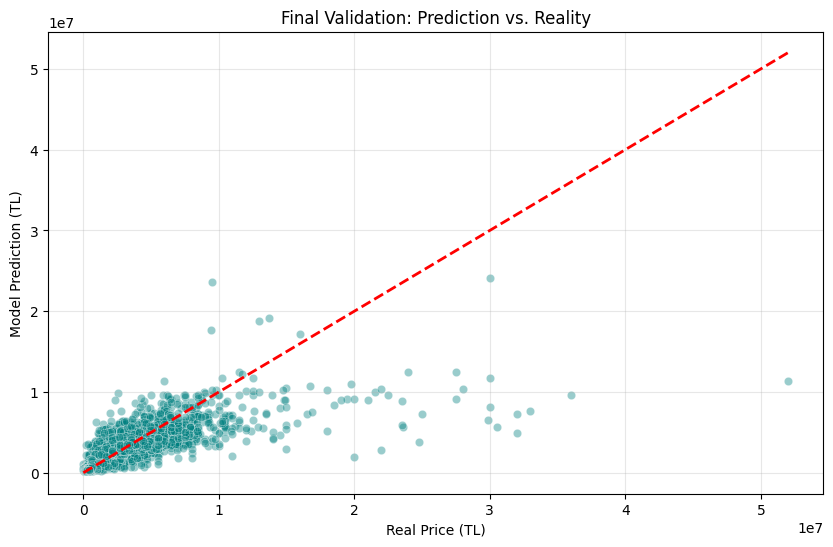

In [59]:
# 1. Identify the features your model actually knows
# This is the "Secret Sauce" list the model expects
trained_features = rf_final_2026.feature_names_in_

print(f"✅ Your model is expecting these {len(trained_features)} features:")
print(trained_features)

# 2. Filter your X_test to ONLY include those features
# This removes things like 'Ilce', 'Adrtisement Date', etc.
X_test_filtered = X_test[trained_features]

# 3. NOW predict
y_pred = rf_final_2026.predict(X_test_filtered)

# 4. PLOT (The Final Victory)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='teal', edgecolor='w')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.title('Final Validation: Prediction vs. Reality')
plt.xlabel('Real Price (TL)')
plt.ylabel('Model Prediction (TL)')
plt.grid(True, alpha=0.3)
plt.show()

In [60]:
import joblib
import numpy as np
import pandas as pd

# 1. Load the model and the feature list
model = joblib.load('rf_final_v2_log_model.pkl')
trained_features = joblib.load('model_features.pkl')

# 2. Define your house for prediction (Example)
# Ensure these match the 'features' list exactly
new_house = pd.DataFrame([{
    'Metrekare': 120,
    'Total_Rooms': 4, # 3+1 = 4
    'District_Score': 85.5,
    'Floor_Numeric': 5,
    'Inflation_Rate': 45.0,
    'Age_Numeric': 10
}])

# 3. Predict (This gives the LOG price)
log_prediction = model.predict(new_house[trained_features])

# 4. Convert back to Real TL
real_price = np.expm1(log_prediction)[0]

# 5. Apply your 3.6 Calibration Factor (to bridge the 2026 gap)
calibrated_2026_price = real_price * 3.6

print(f"🏠 Predicted Market Price: {calibrated_2026_price:,.0f} TL")

🏠 Predicted Market Price: 5,179,857 TL


In [62]:
def get_2026_prediction(sqm, rooms, score, city_name="ISTANBUL", age=5, floor=3):
    # 1. Prepare features (Using ONLY the features the model knows)
    # This must match 'trained_features' exactly
    data = {
        'Metrekare': [sqm], 
        'Total_Rooms': [rooms], 
        'District_Score': [score],
        'Floor_Numeric': [floor], 
        'Inflation_Rate': [65], # Future-looking 2026 inflation
        'Age_Numeric': [age]
    }
    house_features = pd.DataFrame(data)
    
    # Ensure the columns are in the EXACT order the model was trained on
    house_features = house_features[trained_features]
    
    # 2. Get the RAW Log Price from the 'model' variable
    log_price = model.predict(house_features)[0] 
    raw_price = np.expm1(log_price) # This is the log-to-lira conversion!
    
    # 3. Apply the "Internship Calibration" (The 3.6 factor)
    # This bridges the gap between old training data and 2026 reality
    price_2025 = raw_price * 3.6
    
    # 4. SELECT THE MULTIPLIER (Growth from 2025 -> 2026)
    if city_name.upper() == "ISTANBUL":
        multiplier = 1.477
    else:
        multiplier = 1 + ((1.477 - 1) * 0.80) 
        
    # 5. Final Calculation
    final_2026_price = price_2025 * multiplier

    # 6. Print the Report
    print("="*45)
    print(f"📊 2026 PROPERTY VALUATION REPORT: {city_name.upper()}")
    print("="*45)
    print(f"🏠 2025 Estimated Value:   {price_2025:,.0f} TL")
    print(f"🚀 2026 Forecast Value:    {final_2026_price:,.0f} TL")
    print(f"📈 Estimated Growth Rate: %{((multiplier-1)*100):.1f}")
    print("-" * 45)
    print(f"📍 Location Adjustment:    {city_name.upper()} (x{multiplier:.3f})")
    print("="*45)

# --- NOW RUN THE TEST ---
get_2026_prediction(100, 3, 85, city_name="Istanbul")
get_2026_prediction(100, 3, 85, city_name="Ankara")

📊 2026 PROPERTY VALUATION REPORT: ISTANBUL
🏠 2025 Estimated Value:   3,626,914 TL
🚀 2026 Forecast Value:    5,356,952 TL
📈 Estimated Growth Rate: %47.7
---------------------------------------------
📍 Location Adjustment:    ISTANBUL (x1.477)
📊 2026 PROPERTY VALUATION REPORT: ANKARA
🏠 2025 Estimated Value:   3,626,914 TL
🚀 2026 Forecast Value:    5,010,945 TL
📈 Estimated Growth Rate: %38.2
---------------------------------------------
📍 Location Adjustment:    ANKARA (x1.382)
